# Self-Validating Bayesian Optimization for Cu₃VS₄ Nanoparticle Synthesis

## Clean Execution Notebook

This notebook provides a clean interface to the self-validating Bayesian optimization system.

**All model code is in Python modules:**
- `cuvs_optimizer.py` - Base optimizer with GP models
- `cuvs_selfvalidating.py` - Self-validation system with error learning

**This notebook is just for execution and visualization.**


In [1]:
# =============================================================================
# IMPORTS & SETUP
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

# Import the self-validating optimizer
import sys
sys.path.insert(0, str(Path("..").resolve() / "src"))

from cuvs_selfvalidating import (
    SelfValidatingOptimizer,
    # Visualization functions
    plot_recommendation_history,
    plot_parity,
    plot_calibration,
    plot_error_learning_progress,
    plot_error_correction_impact,
    plot_target_achievement,
    plot_feature_importance,
    plot_classifier_calibration,
    plot_collinearity_heatmap,
    plot_dataset_quality_dashboard,
    # Diagnostic functions
    compare_feature_modes,
    detect_extrapolation,
    diagnose_collinearity,
    # Utilities
    print_model_assessment,
    display_recommendations_table,
    COLORS,
)

# Set up paths
DATA_DIR = Path("..") / "data"
OUTPUT_DIR = Path("..") / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Publication style
def set_publication_style():
    plt.rcParams.update({
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'figure.figsize': (8, 5),
        'axes.linewidth': 0.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.family': 'sans-serif',
    })

set_publication_style()

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✓ All imports successful!")
print(f"✓ Data directory: {DATA_DIR.resolve()}")
print(f"✓ Output directory: {OUTPUT_DIR.resolve()}")


✓ Cu3VS4 Optimizer module loaded
  Features available: raw, chemical, hybrid
  Enhanced features: ['effective_dielectric']
  Diagnostic functions: compare_feature_modes, detect_extrapolation, diagnose_collinearity
  Calibration: classifier_calibration_metrics, evaluate_all_classifiers
✓ Self-Validating BO module loaded
  Classes: ExperimentStore, RecommendationStore, ErrorLearner, SelfValidatingOptimizer
  Visualization: plot_recommendation_history, plot_parity, plot_calibration, plot_error_learning_progress,
                plot_error_correction_impact, plot_target_achievement, plot_feature_importance,
                plot_classifier_calibration, plot_collinearity_heatmap, plot_dataset_quality_dashboard
  Diagnostics: compare_feature_modes, detect_extrapolation, diagnose_collinearity
  Utilities: print_model_assessment, display_recommendations_table
✓ All imports successful!
✓ Data directory: /Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/data
✓ Output directory: /

## 1. Initialize the Optimizer

This will:
- Load experiments from JSON (or import from CSV if first run)
- Build GP models with improved regularization (alpha=1e-4)
- Load any existing recommendation history
- Initialize error learner (activates after 6 completed recommendations = 3 batches)

In [2]:
# Initialize the self-validating optimizer
# 
# RECOMMENDED: Use 'smart_hybrid' mode (auto-removes collinear features)
# See docs/FEATURE_MODES.md for details on each mode
#
optimizer = SelfValidatingOptimizer(
    data_dir=DATA_DIR,
    initialize_from_csv=True,  # Only imports if experiments.json doesn't exist
    feature_mode='smart_hybrid'  # RECOMMENDED: Eliminates collinearity automatically
)

# Alternative modes (comment out line above and uncomment one below to switch):
# 
# optimizer = SelfValidatingOptimizer(
#     data_dir=DATA_DIR,
#     initialize_from_csv=True,
#     feature_mode='raw'       # 5 features: just Temp, Time, VOacac, DDT, OAm
# )
# 
# optimizer = SelfValidatingOptimizer(
#     data_dir=DATA_DIR,
#     initialize_from_csv=True,
#     feature_mode='chemical'  # 6-7 features: derived chemical descriptors only
# )
# 
# optimizer = SelfValidatingOptimizer(
#     data_dir=DATA_DIR,
#     initialize_from_csv=True,
#     feature_mode='hybrid'    # 8 features: raw + chemical (WARNING: severe collinearity)
# )

# Print current status
optimizer.print_status()



Building base optimizer (Cu3VS4Optimizer) on 45 successful experiments...

Selecting smart hybrid features (threshold |r| > 0.8)...
  ✓ Keep Temp         (max |r| = 0.325 with log_Time)
  ✗ Drop Time         (|r| = 0.959 with log_Time) → requires log_Time for reconstruction
  ✗ Drop VOacac       (|r| = 1.000 with Metal_Conc) → requires Cu_V_ratio for reconstruction
  ✓ Keep DDT          (max |r| = 0.772 with S_Metal_ratio)
  ✗ Drop OAm          (|r| = 0.980 with effective_dielectric) → requires Ligand_Metal_ratio for reconstruction

✓ Smart Hybrid Mode: 7 features selected
  Raw features kept: ['Temp', 'DDT']
  Chemical features: ['Ligand_Metal_ratio', 'log_Time', 'Cu_V_ratio', 'Metal_Conc', 'effective_dielectric']
  Dropped 3 collinear raw features:
    Time → replaced by log_Time (|r|=0.959)
    VOacac → replaced by Metal_Conc (|r|=1.000)
    OAm → replaced by effective_dielectric (|r|=0.980)
Building models with 7 features (smart_hybrid mode)...
  Regression models fitted (n=45)
  

## 1b. Model Diagnostics (Recommended)

Run comprehensive diagnostics to verify model quality before generating recommendations.

This checks:
- **LOO-CV metrics**: R², RMSE, and uncertainty calibration for each property
- **Collinearity (VIF)**: Detects problematic feature correlations
- **Classifier calibration**: Verifies feasibility predictions are well-calibrated
- **Sample size adequacy**: Warns if too few samples per feature

In [3]:
# =============================================================================
# RUN COMPREHENSIVE MODEL DIAGNOSTICS
# =============================================================================

# Full diagnostic report (LOO-CV, collinearity, classifier calibration)
diagnostics = optimizer.full_diagnostics()

# Optional: Compare feature modes to verify 'hybrid' is the best choice
# Now includes 'smart_hybrid' which auto-removes collinear raw features
# Uncomment to run (takes ~2-3 minutes as it fits models for each mode)
comparison_df = optimizer.compare_feature_modes(modes=['raw', 'chemical', 'hybrid', 'smart_hybrid'])


COMPREHENSIVE MODEL DIAGNOSTICS

Feature mode: smart_hybrid
Features (7): ['Temp', 'DDT', 'Ligand_Metal_ratio', 'log_Time', 'Cu_V_ratio', 'Metal_Conc', 'effective_dielectric']
Training samples: 55 total, 45 successful
✓ Samples per feature ratio: 6.4

--- LOO-CV Regression Metrics ---
No LOO-CV metrics available. Run with validate=True.

--- Collinearity Diagnostics ---
✓ No severe collinearity detected
             Feature      VIF       Interpretation
  Ligand_Metal_ratio 8.057857 ⚠ Moderate (caution)
effective_dielectric 6.612930 ⚠ Moderate (caution)
          Metal_Conc 5.780649 ⚠ Moderate (caution)
          Cu_V_ratio 5.394604 ⚠ Moderate (caution)
                 DDT 1.502455   ✓ Low (acceptable)
            log_Time 1.261741   ✓ Low (acceptable)
                Temp 1.139254   ✓ Low (acceptable)

--- Classifier Calibration ---
HasProduct: Brier=0.0285, ECE=0.1467
  ✓ Excellent calibration (Brier < 0.1)
PhasePure: Brier=0.1368, ECE=0.1155
  ✓ Good calibration (Brier < 0.2)
IsCu

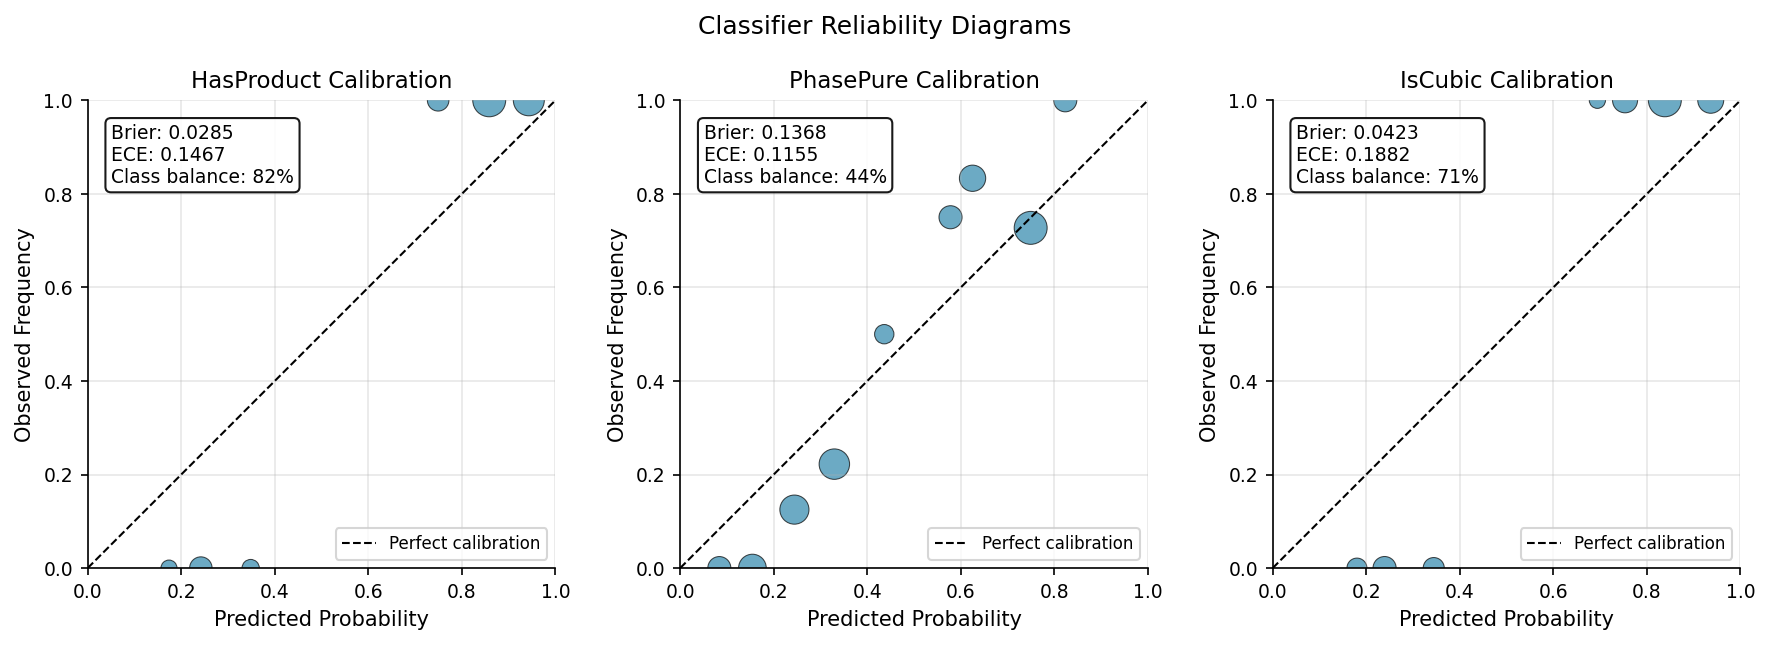


⚠️ Highly correlated pairs (|r| > 0.8):
   Cu_V_ratio ↔ Metal_Conc: r = -0.881


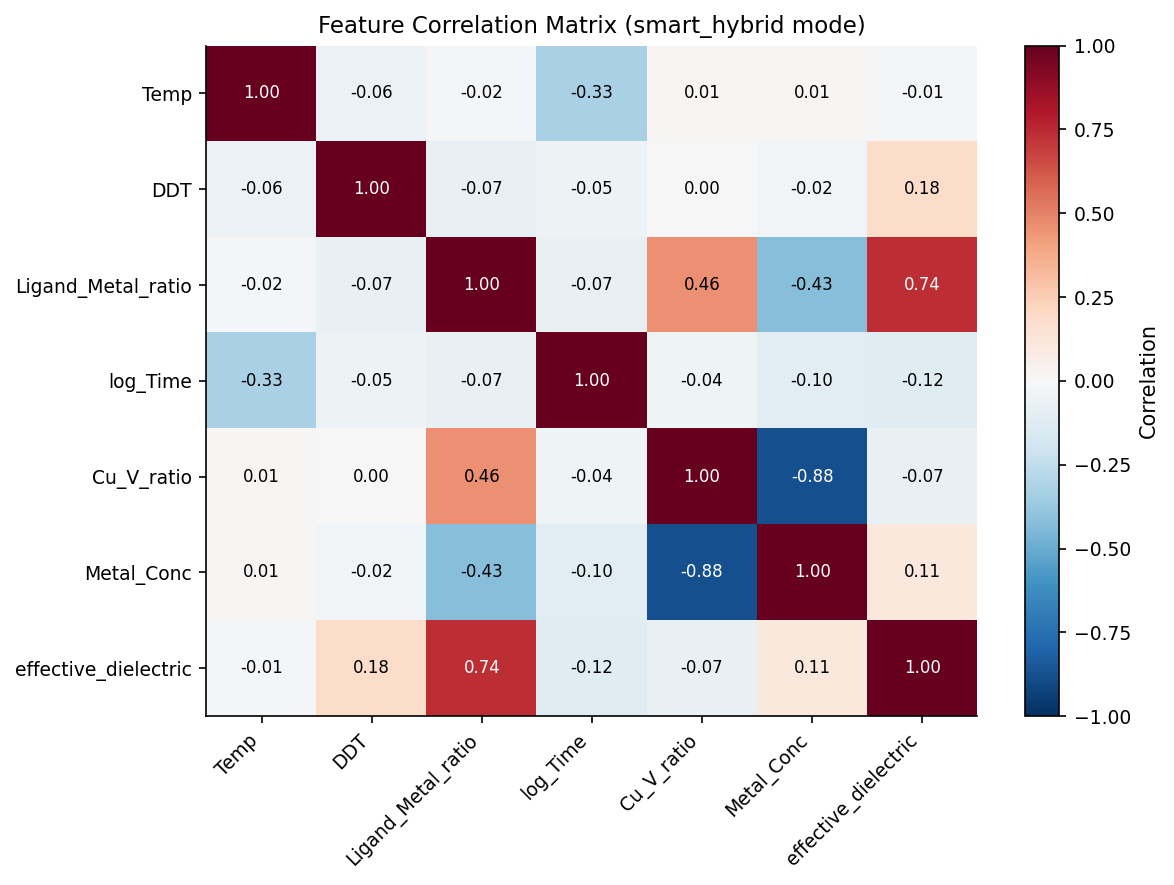

In [4]:
# =============================================================================
# DIAGNOSTIC VISUALIZATIONS
# =============================================================================
from cuvs_selfvalidating import plot_classifier_calibration, plot_collinearity_heatmap

# Plot classifier calibration (reliability diagrams)
fig_cal = plot_classifier_calibration(optimizer)
if fig_cal:
    plt.savefig(OUTPUT_DIR / "classifier_calibration.png", dpi=150, bbox_inches='tight')
    plt.show()

# Plot feature correlation heatmap
fig_corr = plot_collinearity_heatmap(optimizer)
if fig_corr:
    plt.savefig(OUTPUT_DIR / "feature_correlations.png", dpi=150, bbox_inches='tight')
    plt.show()

## 1c. Dataset Quality Dashboard (For Presentations)

Generate a comprehensive 4-panel dashboard summarizing dataset quality:
1. **Design Space Coverage**: Experimental diversity in parameter space
2. **Outcome Distributions**: Range of achieved Size, GSD, Squareness
3. **Dataset Composition**: Success rate and sample size adequacy
4. **Model Performance**: LOO-CV R² comparison across feature modes

Building models with 5 features (raw mode)...
  Regression models fitted (n=45)
  HasProduct classifier fitted
  PhasePure classifier fitted
  IsCubic classifier fitted

Running LOO cross-validation...
  Size: R²=0.063, RMSE=7.840
  GSD: R²=0.103, RMSE=0.167
  Squareness: R²=-0.034, RMSE=0.067
Building models with 6 features (chemical mode)...
  Regression models fitted (n=45)
  HasProduct classifier fitted
  PhasePure classifier fitted
  IsCubic classifier fitted

Running LOO cross-validation...
  Size: R²=0.272, RMSE=6.910
  GSD: R²=-0.221, RMSE=0.195
  Squareness: R²=-0.351, RMSE=0.076
Building models with 8 features (hybrid mode)...
  Regression models fitted (n=45)
  HasProduct classifier fitted
  PhasePure classifier fitted
  IsCubic classifier fitted

Running LOO cross-validation...
  Size: R²=-0.004, RMSE=8.117
  GSD: R²=0.090, RMSE=0.168
  Squareness: R²=0.018, RMSE=0.065

Selecting smart hybrid features (threshold |r| > 0.8)...
  ✓ Keep Temp         (max |r| = 0.325 with log_

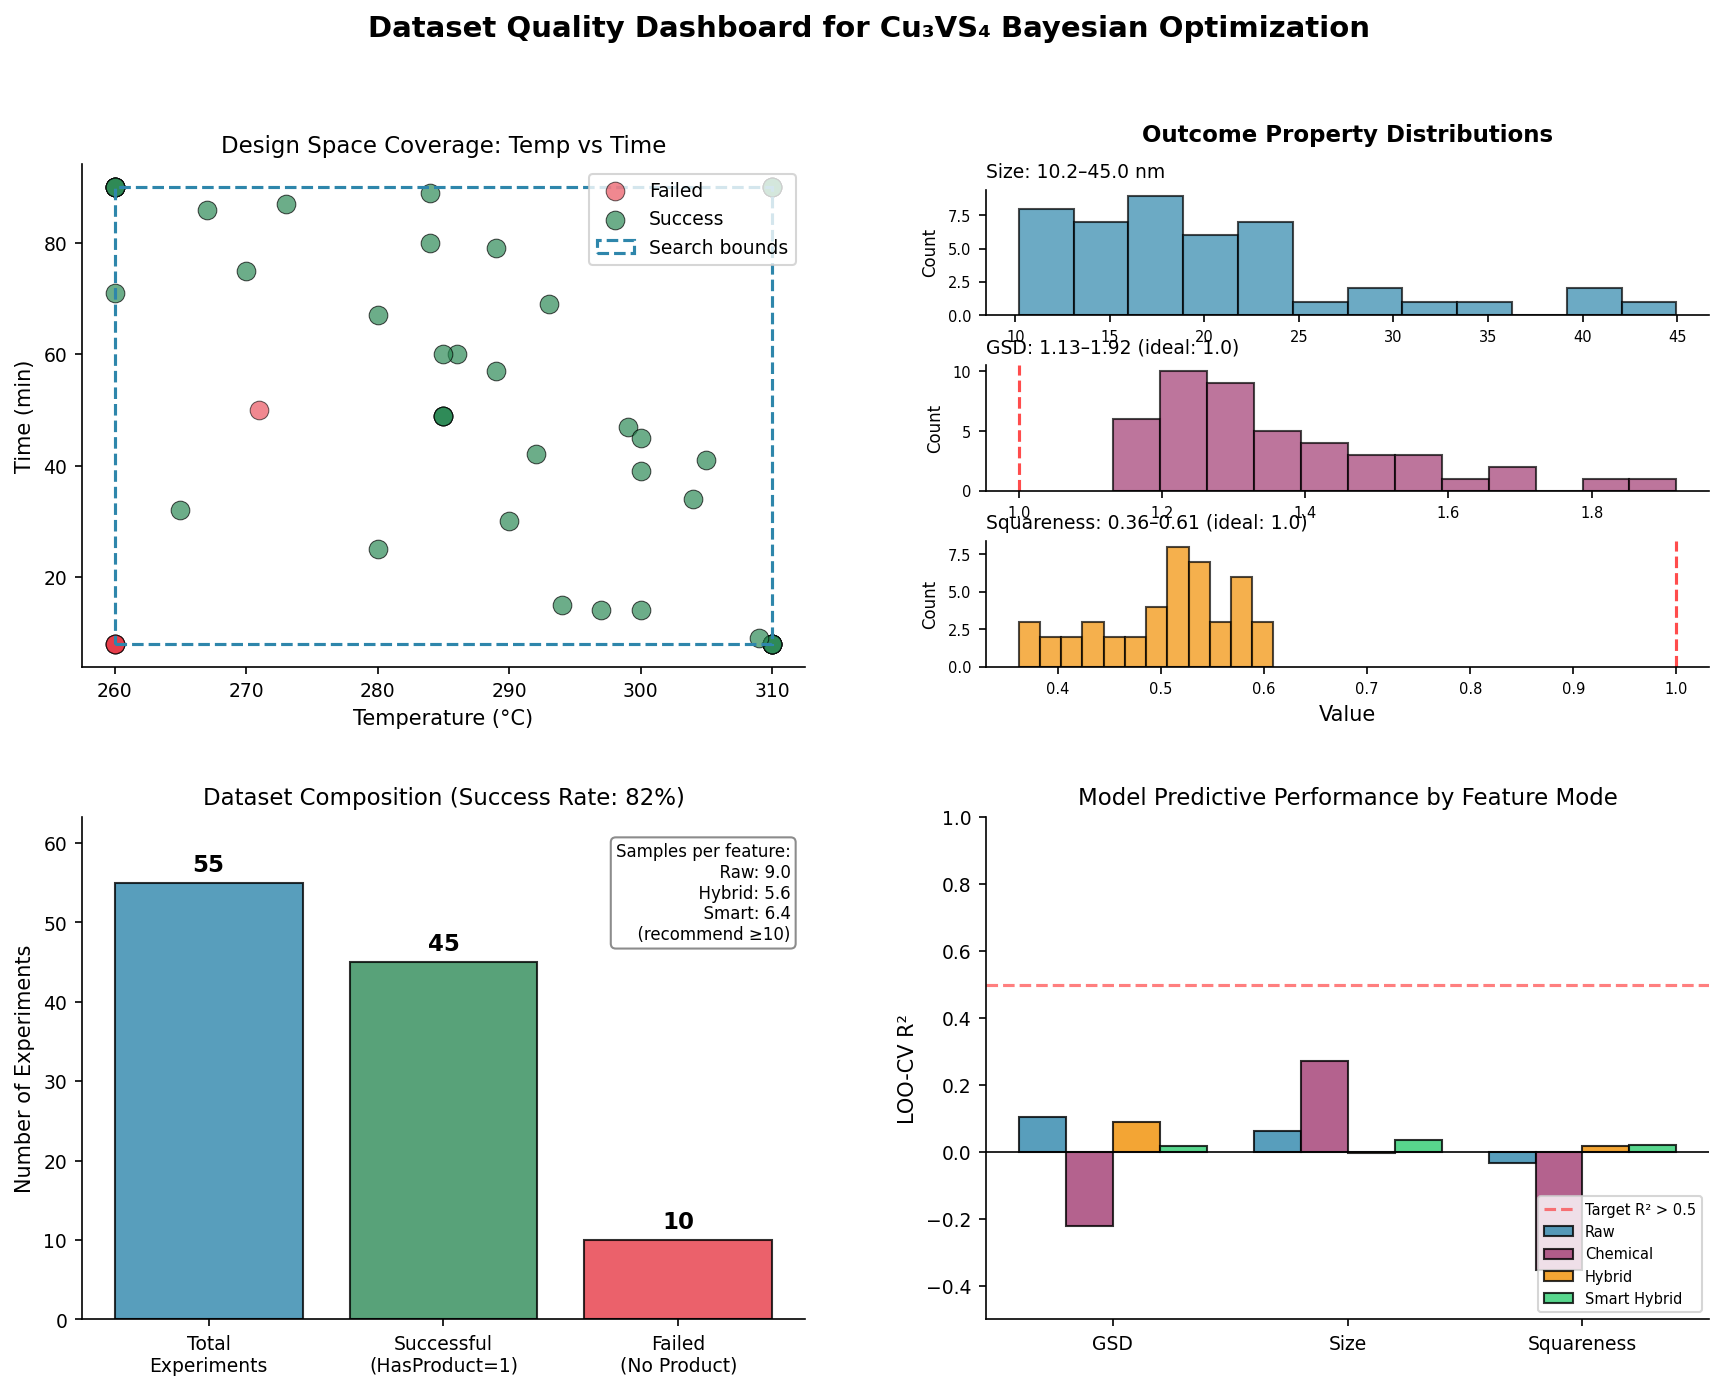


✓ Dashboard saved to: ../outputs/dataset_quality_dashboard.png


In [5]:
# =============================================================================
# DATASET QUALITY DASHBOARD (for presentations)
# =============================================================================

# Generate comprehensive dashboard
fig_dashboard = plot_dataset_quality_dashboard(
    optimizer,
    figsize=(14, 10),
    save_path=OUTPUT_DIR / "dataset_quality_dashboard.png"
)

if fig_dashboard:
    plt.show()
    print(f"\n✓ Dashboard saved to: {OUTPUT_DIR / 'dataset_quality_dashboard.png'}")

## 2. Generate Recommendations

Request synthesis recommendations for a target particle size.

In [6]:
# Set your target particle size (nm)
TARGET_SIZE = 15.0  # <-- MODIFY THIS
SIZE_TOLERANCE = 1.0  # Acceptable range: target ± tolerance

# Generate recommendations
recommendations = optimizer.recommend(
    target_size=TARGET_SIZE,
    size_tol=SIZE_TOLERANCE,
    seed=42  # For reproducibility
)

# Display nicely formatted
display_recommendations_table(recommendations)

# Also show as DataFrame
display(recommendations)



GENERATING RECOMMENDATIONS
Target: 15.0 ± 1.0 nm
Base optimizer: smart_hybrid mode
Correction applied: False

✓ Generated 2 recommendations (IDs: ['REC_001', 'REC_002'])
  These are now PENDING in the recommendation store.
  After running experiments, use complete_recommendation() to log results.

SYNTHESIS RECOMMENDATIONS

🔬 Recommendation 1: REC_001
   Conditions:
      Temp: 307.7°C | Time: 41.0 min | VOacac: 0.172 mmol
      DDT: 1.97 mL | OAm: 3.64 mL
   Predictions:
      Size: 14.5 ± 3.3 nm
      GSD: 1.286 | Squareness: 0.597
   Feasibility: 60%

🔬 Recommendation 2: REC_002
   Conditions:
      Temp: 308.1°C | Time: 49.5 min | VOacac: 0.235 mmol
      DDT: 2.29 mL | OAm: 3.46 mL
   Predictions:
      Size: 15.6 ± 2.7 nm
      GSD: 1.360 | Squareness: 0.592
   Feasibility: 68%

--------------------------------------------------------------------------------
To complete a recommendation after running the experiment:
  optimizer.complete_recommendation('REC_XXX', Size=..., GSD=..

,Rank,Rec_ID,Temp,Time,VOacac,DDT,OAm,Pred_Size,Pred_Size_Std,Pred_GSD,Pred_Squareness,P_Feasible,Extrapolation_Distance,Is_Extrapolating
0,1,REC_001,307.708,40.986,0.172,1.974,3.639,14.51,3.34,1.286,0.597,0.600,0.647210,False
1,2,REC_002,308.060,49.534,0.235,2.294,3.455,15.56,2.73,1.360,0.592,0.677,0.498822,False


## 3. View Pending Recommendations

See what recommendations are waiting for experimental results.

In [7]:
# View pending recommendations
pending = optimizer.get_pending_recommendations()
display(pending)


,Rec_ID,Date,Target_Size,Temp,Time,VOacac,DDT,OAm,Pred_Size,Pred_GSD
0,REC_001,2026-01-30,15.0,307.708,40.986,0.172,1.974,3.639,14.5 ± 3.3,1.286
1,REC_002,2026-01-30,15.0,308.060,49.534,0.235,2.294,3.455,15.6 ± 2.7,1.360


## 4. Complete Recommendations (After Running Experiments)

After you run an experiment in the lab, use this to log the actual results.

In [8]:
# Uncomment and fill in when you have results:

# errors = optimizer.complete_recommendation(
#     rec_id='REC_001',      # <-- Change to your recommendation ID
#     Size=20.5,             # <-- Your measured size (nm)
#     GSD=1.25,              # <-- Your measured GSD
#     Squareness=0.65,       # <-- Your measured squareness
#     HasProduct=1,          # 1 if product formed, 0 if not
#     PhasePure=1,           # 1 if phase pure, 0 if not
#     Polymorph='cubic'      # 'cubic', 'tetragonal', 'multipod', etc.
# )

# After completing, view the model assessment:
# print_model_assessment(optimizer)


## 5. Model Assessment & Visualization

View the model's self-assessment and visualize prediction accuracy.

In [9]:
# Model self-assessment report
print_model_assessment(optimizer)



MODEL SELF-ASSESSMENT REPORT

📊 EXPERIMENT DATABASE
   Total experiments:        55
   ├─ Imported (initial):    55
   ├─ From recommendations:  0
   └─ Manual additions:      0

📋 RECOMMENDATION HISTORY
   Total recommendations:    2
   ├─ Pending:               2
   ├─ Completed:             0
   └─ Skipped:               0

📈 PREDICTION ACCURACY
   Insufficient data (0 completed, need ≥2)

🔧 ERROR CORRECTION STATUS
   Status: ⏳ INACTIVE (need 6 completed recommendations, have 0)



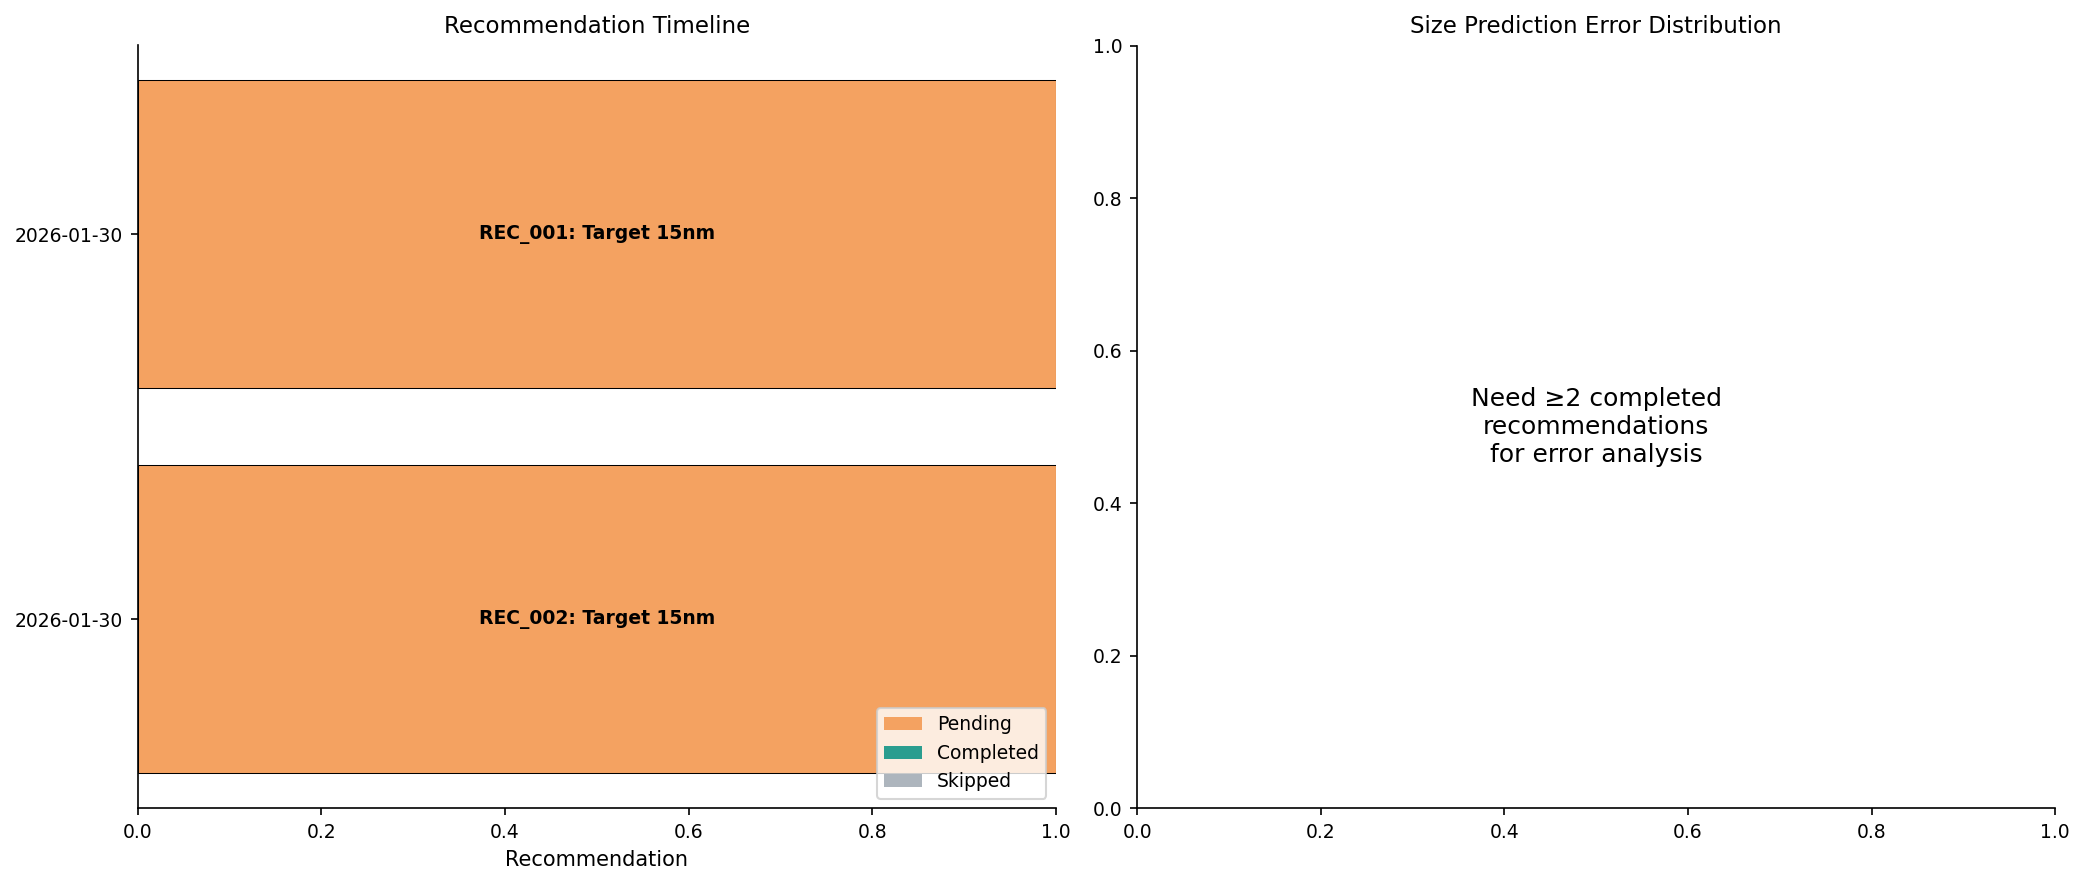

In [10]:
# Visualization: Recommendation History
fig = plot_recommendation_history(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'recommendation_history.png', dpi=300, bbox_inches='tight')
    plt.show()


In [11]:
# Visualization: Parity Plots (Predicted vs Actual)
fig = plot_parity(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'parity_plots_recommendations.png', dpi=300, bbox_inches='tight')
    plt.show()


Need at least 2 completed recommendations for parity plots. Currently have 0.


In [12]:
# Visualization: Calibration Analysis
fig = plot_calibration(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'calibration_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


Need at least 3 completed recommendations for calibration analysis. Have 0.


## 6. Additional Visualizations

### Error Correction Impact
Compare predictions with vs without error correction to see the value of self-validation.

### Target Achievement Tracking
Track how well recommendations achieve target sizes over time.

### Feature Importance
Visualize which synthesis parameters matter most for each property.

In [13]:
# Visualization: Error Correction Impact (compares with vs without correction)
fig = plot_error_correction_impact(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'error_correction_impact.png', dpi=300, bbox_inches='tight')
    plt.show()


Need at least 2 completed recommendations. Have 0.


In [14]:
# Visualization: Target Achievement Tracking
fig = plot_target_achievement(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'target_achievement.png', dpi=300, bbox_inches='tight')
    plt.show()


Need at least 2 completed recommendations. Have 0.


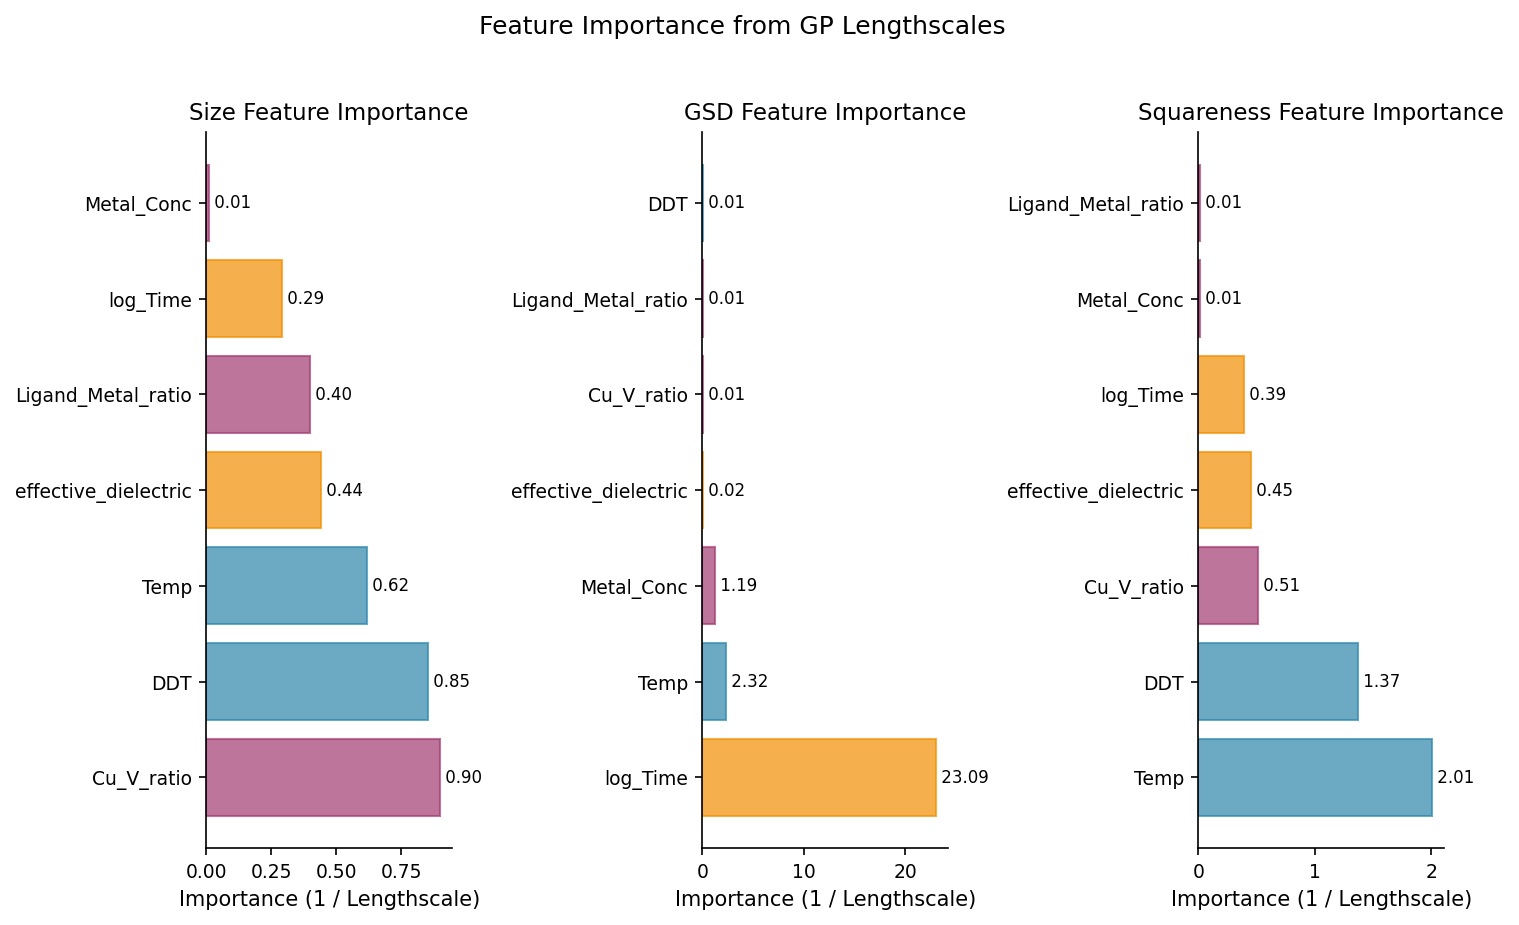

In [15]:
# Visualization: Feature Importance
fig = plot_feature_importance(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()


In [16]:
# Visualization: Error Learning Progress
fig = plot_error_learning_progress(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'learning_progress.png', dpi=300, bbox_inches='tight')
    plt.show()


Need at least 3 completed recommendations. Have 0.


## 6. Additional Operations

### Add Manual Experiments
Add experiments you designed yourself (not from recommendations).

### Test Predictions
Predict outcomes for specific conditions without making a recommendation.

In [17]:
# Add a manual experiment (not from recommendation)
# Uncomment and fill in:

# exp_id = optimizer.add_manual_experiment(
#     Temp=285.0,
#     Time=30.0,
#     VOacac=0.25,
#     DDT=3.0,
#     OAm=4.0,
#     Size=19.5,
#     GSD=1.30,
#     Squareness=0.62,
#     HasProduct=1,
#     PhasePure=1,
#     Polymorph='cubic'
# )
# print(f"Added: {exp_id}")


In [18]:
# Test predictions for specific conditions (without making a recommendation)
result = optimizer.predict_from_conditions(
    Temp=285.0,
    Time=30.0,
    VOacac=0.20,
    DDT=3.0,
    OAm=4.5,
    verbose=True
)



PREDICTION RESULTS

Conditions:
  Temp: 285.0°C, Time: 30.0 min, VOacac: 0.2 mmol
  DDT: 3.0 mL, OAm: 4.5 mL

Base Optimizer: smart_hybrid mode

Predictions (base model):
  Size:       15.25 ± 3.60 nm
  GSD:        1.386 ± 0.162
  Squareness: 0.507 ± 0.037

Feasibility:
  P(Product):    0.926
  P(Phase Pure): 0.481
  P(Cubic):      0.940
  P(Feasible):   0.419
